# 07 Sequence-to-Sequence Models

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple **encoder–decoder** (seq2seq) model with LSTM
- Use it for a **toy task** (e.g. reverse sequence or short copy) and see input → output
- Understand why we use encoder–decoder instead of a single RNN for translation/summarization

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 04 "Sequence-to-Sequence Models with Attention for Machine Translation" — translation with attention bolted on; here the bare encoder-decoder underneath it.

---

## 🌍 Real life

**Where is this used?** Seq2seq is used in **machine translation**, **summarization**, **dialogue**, and **speech-to-text**.

**In this notebook we use** an **encoder–decoder** (encoder RNN → context → decoder RNN) to map one sequence to another. We use **seq2seq** (instead of one RNN that reads and writes in one pass) **because** input and output can have **different lengths**; the encoder summarizes the input into a context, and the decoder generates the output step by step.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Encoder:** Reads the input sequence and produces a **context vector** (e.g. last hidden state or attention over encoder outputs).
- **Decoder:** Starts from the context (and optionally a start token) and generates the output sequence step by step.
- **Seq2seq:** Input length can differ from output length; encoder summarizes, decoder generates.
- **We use encoder–decoder** instead of a single RNN when input and output lengths differ (e.g. translation) or when we need a clear "read then write" structure.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use a **toy task**: fixed-length integer sequences (e.g. copy or reverse) so we don't need a translation dataset.

**Dataset:** Synthetic — toy integer sequences (no download; used to demonstrate encoder–decoder).

**Outputs:** Model structure, one example input → output (or loss over a few steps), and a short explanation.

## Step 1: Imports and create toy sequences (we use a simple copy task so seq2seq runs in ~5 min)

In [1]:
# WHAT: create the toy task - the model must output each 5-digit sequence reversed.
# WHY: reversal is the simplest task where output ORDER differs from input order - exactly what seq2seq solves.
import numpy as np

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # 2,000 random sequences of digits 1-9; the target y is simply the input flipped left-to-right.
    seq_len = 5
    vocab_size = 10
    n_samples = 2000  # enough examples for the model to actually learn the task
    np.random.seed(42)
    x = np.random.randint(1, vocab_size, (n_samples, seq_len))
    y = x[:, ::-1]
    print("Input shape:", x.shape, "Output shape:", y.shape)
    print("Example: input", x[0].tolist(), "-> target (reversed)", y[0].tolist())
else:
    print("Install TensorFlow: pip install tensorflow")

Input shape: (2000, 5) Output shape: (2000, 5)
Example: input [7, 4, 8, 5, 7] -> target (reversed) [7, 5, 8, 4, 7]


## Step 2: Build encoder–decoder (we use encoder–decoder instead of one RNN because input and output are separate sequences)

In [2]:
# WHAT: build the encoder-decoder (seq2seq) model out of two LSTMs.
# WHY: the encoder compresses the input into its final states; the decoder starts FROM those states to write the output.
if HAS_TF:
    # Encoder: read the sequence and keep only the final hidden + cell states (the 'thought vector').
    encoder_inp = keras.Input(shape=(seq_len,))
    emb = keras.layers.Embedding(vocab_size, 32)(encoder_inp)
    _, state_h, state_c = keras.layers.LSTM(32, return_state=True)(emb)
    encoder_states = [state_h, state_c]

    # Decoder: a second LSTM initialized with the encoder's states, predicting one output token per step.
    decoder_inp = keras.Input(shape=(seq_len,))
    emb_dec = keras.layers.Embedding(vocab_size, 32)(decoder_inp)
    decoder_lstm = keras.layers.LSTM(32, return_sequences=True, return_state=True)
    dec_out, _, _ = decoder_lstm(emb_dec, initial_state=encoder_states)
    out = keras.layers.Dense(vocab_size, activation="softmax")(dec_out)

    model = keras.Model([encoder_inp, decoder_inp], out)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 5, 32)     │        320 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 5, 32)     │        320 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 32),      │      8,320 │ embedding[0][0]   │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 5, 32),   │      8,320 │ embedding_1[0][0… │
│                     │ (None, 32),       │            │ lstm[0][1],       │
│                     │ (None, 32)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 10)     │        330 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,610 (68.79 KB)

 Trainable params: 17,610 (68.79 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Prepare decoder input (shift right: [START] + target[:-1]) and train (30 epochs, a few seconds)

In [3]:
# WHAT: train with teacher forcing, then inspect a few predictions.
# WHY: during training the decoder is fed the correct PREVIOUS token (shifted targets) - this is teacher forcing.
if HAS_TF:
    # Build decoder inputs by shifting the targets one step right; position 0 gets a start token (0).
    dec_inp = np.zeros_like(y)
    dec_inp[:, 1:] = y[:, :-1]
    dec_inp[:, 0] = 0
    y_one_step = y
    history = model.fit([x, dec_inp], y_one_step, epochs=30, batch_size=32, verbose=0)
    for e in (0, 9, 19, 29):
        print(f"Epoch {e+1:2d}: loss={history.history['loss'][e]:.4f}  "
              f"accuracy={history.history['accuracy'][e]:.4f}")
    # Compare a few predicted sequences against the true reversed targets.
    pred = model.predict([x[:3], dec_inp[:3]], verbose=0)
    pred_class = np.argmax(pred, axis=-1)
    print("\nSample predictions (target vs pred):")
    for i in range(3):
        print("  target:", y[i].tolist(), "pred:", pred_class[i].tolist())

Epoch  1: loss=2.1991  accuracy=0.2365
Epoch 10: loss=0.1719  accuracy=0.9840
Epoch 20: loss=0.0522  accuracy=0.9983
Epoch 30: loss=0.0452  accuracy=0.9940

Sample predictions (target vs pred):
  target: [7, 5, 8, 4, 7] pred: [7, 5, 8, 4, 7]
  target: [4, 5, 8, 7, 3] pred: [4, 5, 8, 7, 3]
  target: [5, 6, 3, 8, 8] pred: [5, 6, 3, 8, 8]


## 🌍 Real-World Worked Example — Stock Trend Prediction (and an Honesty Check)

**Industry context:** Hedge funds and trading platforms really do run LSTMs on price
sequences — and most claimed "prediction accuracy" evaporates once it is compared
against the right baseline.

We train an LSTM to predict whether a **synthetic stock price** goes up or down the
next day. The data is a **random walk with upward drift**: each day's move is drawn
independently of the past, so the *only* learnable signal is the drift itself. That
makes the honest benchmark the **base rate** (always predict the majority direction),
not the 50% coin flip that "stock prediction" demos usually quote. Watch how the
comparison changes the story.

LSTM direction accuracy:          59.2%
Always-predict-majority baseline: 59.2%  (test set is 59.2% 'up' days)
LSTM edge over the honest baseline: +0.0 points

By construction, each day's move is INDEPENDENT of the past 20 days,
so no model can consistently beat the base rate on this data — any gap
either way is test-set noise (~+/-3.6 points at n≈196).
Lesson: always compare a 'market predictor' to the base rate, not to 50%.


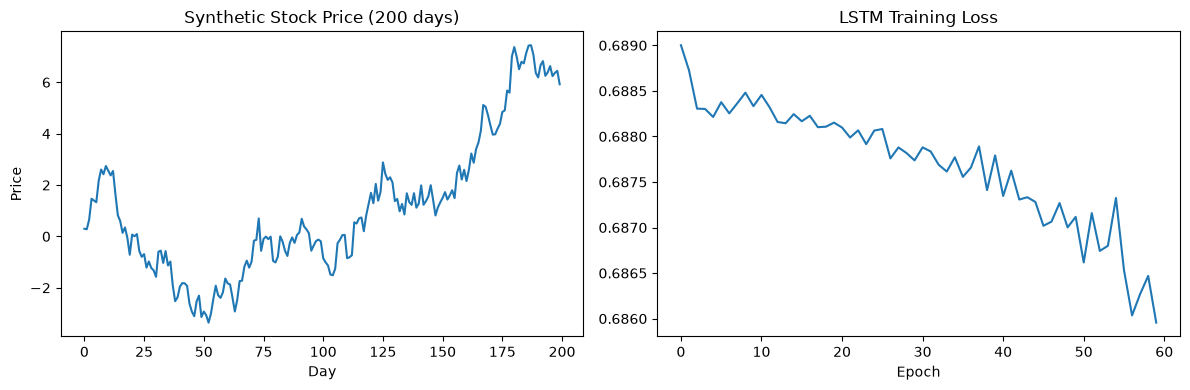

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate a stock-like price series: a RANDOM WALK with drift ─────────
# Each daily step is independent N(+0.05, 0.5) — the past 20 days carry NO
# information about tomorrow beyond the constant drift.
np.random.seed(42)
torch.manual_seed(0)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ──────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# ── Honest evaluation: compare against the base rate, not against 50% ─────
model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
p_up = Yte.float().mean().item()
base = max(p_up, 1.0 - p_up)   # always predict the majority direction

print(f"LSTM direction accuracy:          {acc*100:.1f}%")
print(f"Always-predict-majority baseline: {base*100:.1f}%  (test set is {p_up*100:.1f}% 'up' days)")
print(f"LSTM edge over the honest baseline: {(acc-base)*100:+.1f} points")
print()
print("By construction, each day's move is INDEPENDENT of the past 20 days,")
print("so no model can consistently beat the base rate on this data — any gap")
print("either way is test-set noise (~+/-3.6 points at n≈196).")
print("Lesson: always compare a 'market predictor' to the base rate, not to 50%.")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(price[:200]); plt.title("Synthetic Stock Price (200 days)"); plt.xlabel("Day"); plt.ylabel("Price")
plt.subplot(1,2,2)
plt.plot(losses); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** Change the sequence length (e.g. 5 → 7) in the toy data and retrain. Does the model still learn to reverse? Or try a different task (e.g. copy the sequence instead of reverse).

---

## ✅ Summary

**What you did:** Built an encoder–decoder (LSTM) for a toy reverse-sequence task; trained for 30 epochs until per-token accuracy is near 1.0 and the sample predictions match the reversed targets.

**In real life you'd also:** Use attention over encoder outputs, real translation data, and teacher forcing / scheduled sampling.

**The main idea:** Seq2seq = encoder (summarize input) + decoder (generate output); we use it when input and output lengths differ (e.g. translation).

**Next:** `04_transformer_attention` introduces attention; `05_bert_finetuning` fine-tunes an encoder for classification.

## 📚 References

1. Sutskever, I., Vinyals, O. & Le, Q. V. (2014). *Sequence to Sequence Learning with Neural Networks*. NeurIPS. https://arxiv.org/abs/1409.3215
2. Bahdanau, D., Cho, K. & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR. https://arxiv.org/abs/1409.0473
3. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS. https://arxiv.org/abs/1706.03762